In [114]:
# !pip install seaborn
# !pip install tf-nightly

In [115]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [116]:
DATASET_PATH = 'data/mini_speech_commands/rosy/'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
  tf.keras.utils.get_file(
      'mini_speech_commands.zip',
      origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
      extract=True,
      cache_dir='.', cache_subdir='data')

In [117]:
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[commands != 'README.md']
print('Commands:', commands)

Commands: ['mirai' 'noise' 'random' 'similar']


(array([   0.,    0.,    0.,    0.,    0., 1931.,    0.,    0.,    0.,
           0.]),
 array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5]),
 <BarContainer object of 10 artists>)

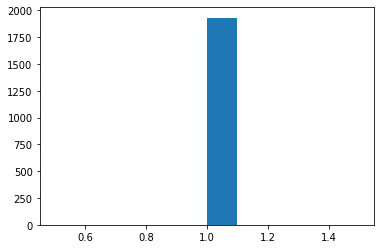

In [118]:
from random import sample
from scipy.io import wavfile
import soundfile

duration_of_recordings=[]
for label in commands:
    waves = [f for f in os.listdir(DATASET_PATH + '/'+ label) if f.endswith('.wav')]
    for wav in waves:
        PATH = DATASET_PATH + '/' + label + '/' + wav
        sample_rate, samples = wavfile.read(PATH)
        soundfile.write(PATH, samples, sample_rate, subtype='PCM_16')

        temp = float(len(samples)/sample_rate)
        duration_of_recordings.append(temp)
        if (temp != 1):
            file_to_rem = pathlib.Path(DATASET_PATH + '/'+ label + '/' + wav).unlink()
plt.hist(np.array(duration_of_recordings))

In [119]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both')

label_names = np.array(train_ds.class_names)
print("label names:", label_names)

Found 1931 files belonging to 4 classes.
Using 1545 files for training.
Using 386 files for validation.
label names: ['mirai' 'noise' 'random' 'similar']


In [120]:
# train_ds.element_specc

In [121]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

In [122]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [123]:
for example_audio, example_labels in train_ds.take(1):  
  print(example_audio.shape)
  print(example_labels.shape)

(64, 16000)
(64,)


In [124]:
# label_names[[1,1,3,0]]

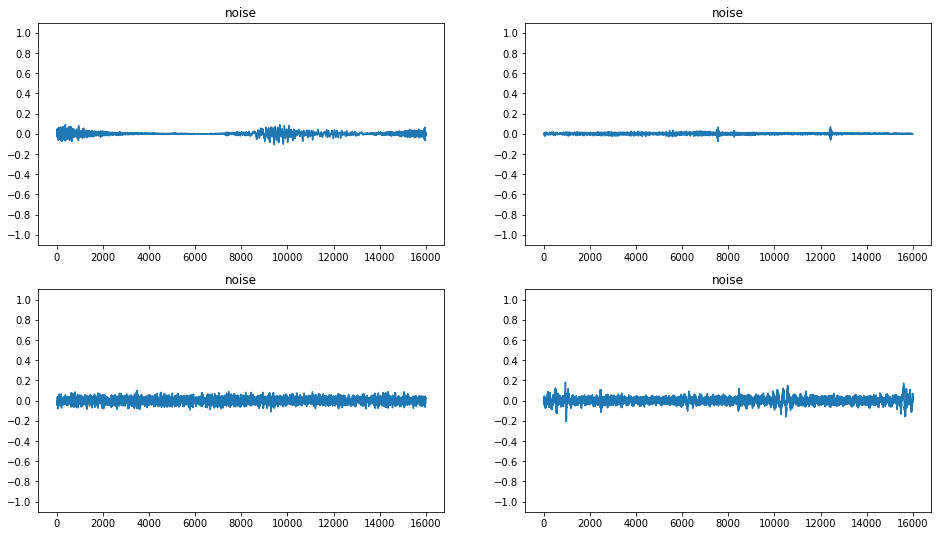

In [125]:
rows = 2
cols = 2
n = rows * cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
  if i>=n:
    break
  r = i // cols
  c = i % cols
  ax = axes[r][c]
  ax.plot(example_audio[i].numpy())
  ax.set_yticks(np.arange(-1.2, 1.2, 0.2))
  label = label_names[example_labels[i]]
  ax.set_title(label)
  ax.set_ylim([-1.1,1.1])

plt.show()

In [126]:
from MFCCs.feature import mfcc

def get_spectrogram(waveform):
  
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)

  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  
  return spectrogram

In [127]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  my_spec = mfcc(waveform, sr=16000, n_mfcc=124)
  print("my_spec shape:", my_spec[0].shape)
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

Hasa

audio_win: [[-0.00000000e+00  7.87236274e-07  4.18784319e-06 ...  1.15674443e-06
   1.04697067e-06  0.00000000e+00]
 [ 0.00000000e+00  2.79281434e-06  9.07187544e-06 ...  1.40308820e-06
   4.41816282e-07  0.00000000e+00]
 [ 0.00000000e+00  5.41157963e-06  2.04251074e-05 ... -1.02071979e-05
  -2.12339574e-06 -0.00000000e+00]
 ...
 [-0.00000000e+00  7.49748824e-08  1.04963842e-06 ... -1.37631161e-05
  -1.92524787e-06  0.00000000e+00]
 [ 0.00000000e+00  8.05980016e-07 -1.24242918e-06 ...  1.08712549e-05
   1.56911711e-06 -0.00000000e+00]
 [-0.00000000e+00 -6.10509789e-07 -1.46735169e-06 ... -2.44201613e-06
  -2.35635342e-07  0.00000000e+00]]
my_spec shape: (124, 41)
Label: noise
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Hasa

audio_win: [[-0.00000000e+00 -1.07669559e-06 -4.07436367e-06 ... -4.35321748e-06
  -1.01860052e-06 -0.00000000e+00]
 [ 0.00000000e+00 -4.64760712e-08 -9.14020736e-07 ... -2.29279778e-06
  -4.95744759e-07 -0.00000000e+00]
 [-0.00000000e+00 -7.86220176e-07 -2.94345659e-06 ... -8.67545147e-07
  -2.86602426e-07 -0.00000000e+00]
 ...
 [-0.00000000e+00 -3.79554586e-07 -8.36561374e-07 ... -3.56313177e-07
  -8.52061261e-08  0.00000000e+00]
 [ 0.00000000e+00  1.31682197e-07  6.19675105e-08 ...  4.02788801e-07
   9.29521424e-08 -0.00000000e+00]
 [ 0.00000000e+00 -1.82031277e-07 -8.98528850e-07 ... -7.28118240e-07
   1.93650297e-08  0.00000000e+00]]
my_spec shape: (124, 41)
Label: noise
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Hasa

audio_win: [[ 0.00000000e+00  4.75414124e-07 -1.35388397e-06 ... -3.92729709e-06
  -3.38474185e-07  0.00000000e+00]
 [ 0.00000000e+00  2.17553637e-06  1.33941500e-05 ... -1.22986403e-05
  -5.36391149e-06 -0.00000000e+00]
 [-0.00000000e+00 -1.42882618e-06 -4.28902172e-06 ...  1.82929358e-06
   1.41590731e-06  0.00000000e+00]
 ...
 [-0.00000000e+00 -3.36407173e-06 -1.48410486e-05 ...  3.52423219e-06
   1.94816442e-06  0.00000000e+00]
 [-0.00000000e+00 -3.40024457e-06 -1.70837419e-05 ...  2.60441797e-06
  -1.60193885e-07 -0.00000000e+00]
 [-0.00000000e+00 -1.43657750e-06 -6.06664017e-06 ... -5.74625581e-06
  -1.21178918e-06 -0.00000000e+00]]
my_spec shape: (124, 41)
Label: noise
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


In [128]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

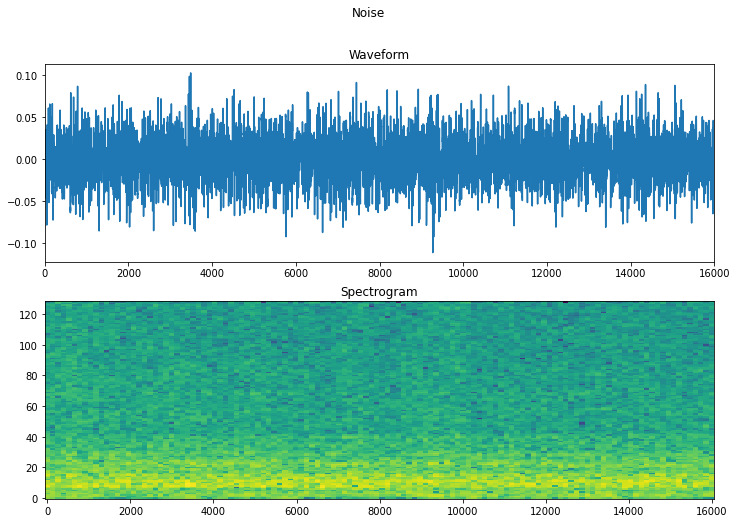

In [129]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

In [130]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [131]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

In [132]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

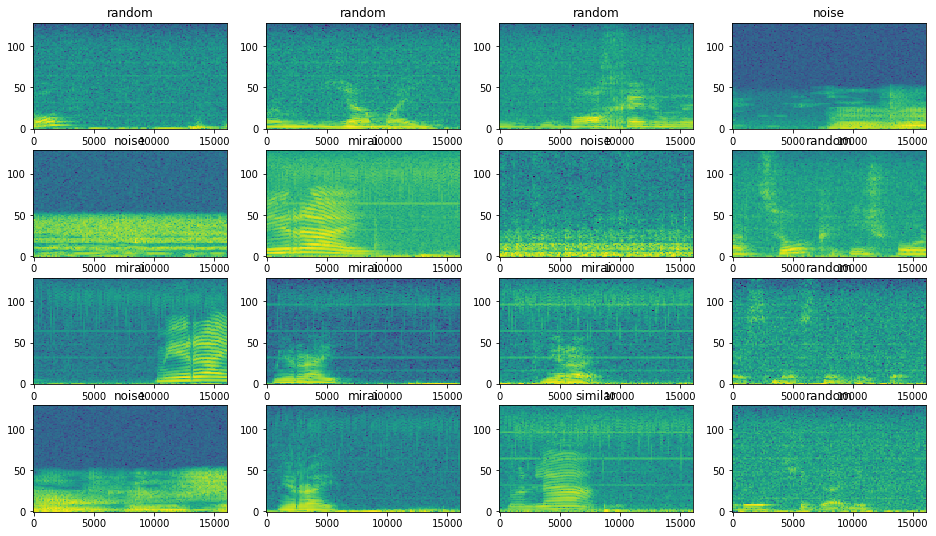

In [133]:
rows = 4
cols = 4
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(commands[example_spect_labels[i].numpy()])

plt.show()

In [134]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(20).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

In [135]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(commands)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (124, 129, 1)
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing_3 (Resizing)       (None, 32, 32, 1)         0         
                                                                 
 normalization_3 (Normalizat  (None, 32, 32, 1)        3         
 ion)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 30, 30, 32)        320       
                                                                 
 conv2d_7 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 dropout_6 (Dropout)       

In [136]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

In [137]:
EPOCHS = 50
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=2),
)

Epoch 1/50
25/25 [==============================] - 4s 124ms/step - loss: 0.8790 - accuracy: 0.5994 - val_loss: 0.7702 - val_accuracy: 0.6094
Epoch 2/50
25/25 [==============================] - 3s 103ms/step - loss: 0.7627 - accuracy: 0.6466 - val_loss: 0.6903 - val_accuracy: 0.7448
Epoch 3/50
25/25 [==============================] - 2s 96ms/step - loss: 0.7185 - accuracy: 0.7159 - val_loss: 0.6576 - val_accuracy: 0.7344
Epoch 4/50
25/25 [==============================] - 3s 113ms/step - loss: 0.6922 - accuracy: 0.7165 - val_loss: 0.6514 - val_accuracy: 0.7396
Epoch 5/50
25/25 [==============================] - 3s 128ms/step - loss: 0.6698 - accuracy: 0.7417 - val_loss: 0.5914 - val_accuracy: 0.7552
Epoch 6/50
25/25 [==============================] - 3s 113ms/step - loss: 0.6265 - accuracy: 0.7612 - val_loss: 0.5675 - val_accuracy: 0.7917
Epoch 7/50
25/25 [==============================] - 3s 122ms/step - loss: 0.6169 - accuracy: 0.7631 - val_loss: 0.5691 - val_accuracy: 0.7552
Epoch 8

Text(0, 0.5, 'Accuracy [%]')

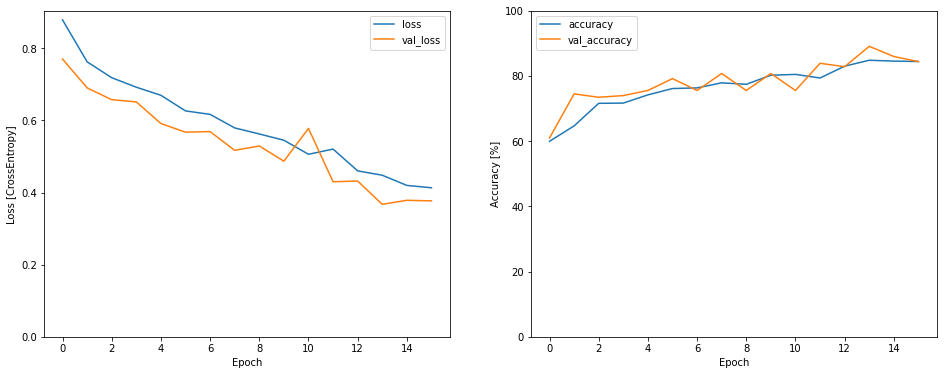

In [138]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

In [139]:
model.evaluate(test_spectrogram_ds, return_dict=True)

4/4 [==============================] - 1s 153ms/step - loss: 0.3636 - accuracy: 0.8557


{'loss': 0.3636164665222168, 'accuracy': 0.8556700944900513}

In [140]:
y_pred = model.predict(test_spectrogram_ds)

4/4 [==============================] - 0s 15ms/step


In [141]:
y_pred = tf.argmax(y_pred, axis=1)

In [142]:
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

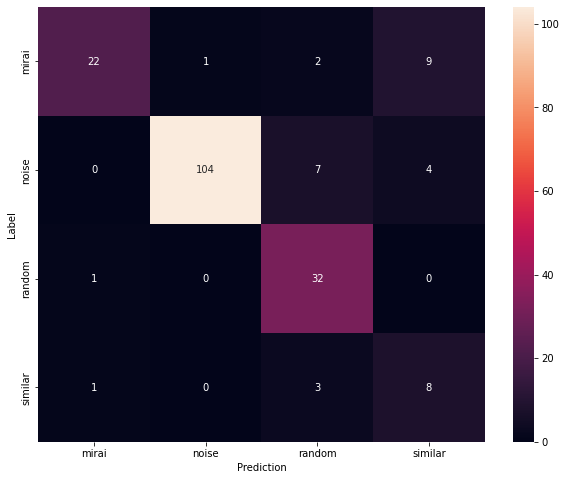

In [143]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=commands,
            yticklabels=commands,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

(16000,)


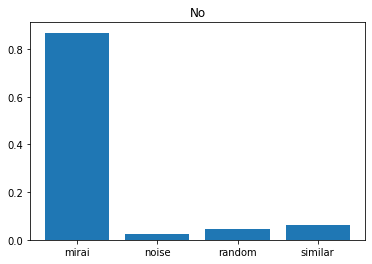

In [144]:
x = data_dir/'mirai/audio_50.wav'
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
print(x.shape)
waveform = x
x = get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
plt.bar(commands, tf.nn.softmax(prediction[0]))
plt.title('No')
plt.show()

display.display(display.Audio(waveform, rate=16000))

In [145]:
import sounddevice as sd

samplerate = 16000

while True:
    recording = sd.rec(int(1*samplerate),samplerate = samplerate , channels = 1, dtype='float32').ravel()
    sd.wait()
    waveform = recording
    recording = get_spectrogram(recording)
    recording = recording[tf.newaxis,...]

    prediction = model(recording)
    pred = tf.nn.softmax(prediction[0])
    pred = tf.math.argmax(pred,0)
    print(commands[pred])


noise
random
random
random
random
random
random
random
random
random
random


KeyboardInterrupt: 

In [ ]:
# waveform = recording
# recording = get_spectrogram(recording)
# recording = recording[tf.newaxis,...]

# prediction = model(recording)
# plt.bar(commands, tf.nn.softmax(prediction[0]))
# plt.title('Prediction')
# plt.show()

# display.display(display.Audio(waveform, rate=16000))

In [ ]:
# pred = tf.nn.softmax(prediction[0])
# pred = tf.math.argmax(pred,0)
# print(pred)

In [167]:
class ExportModel(tf.Module):
  def __init__(self, model):
    self.model = model

    # Accept either a string-filename or a batch of waveforms.
    # YOu could add additional signatures for a single wave, or a ragged-batch. 
    self.__call__.get_concrete_function(
        x=tf.TensorSpec(shape=(), dtype=tf.string))
    self.__call__.get_concrete_function(
       x=tf.TensorSpec(shape=[None, 16000], dtype=tf.float32))


  @tf.function
  def __call__(self, x):
    # If they pass a string, load the file and decode it. 
    if x.dtype == tf.string:
      x = tf.io.read_file(x)
      x, _ = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
      x = tf.squeeze(x, axis=-1)
      x = x[tf.newaxis, :]

    x = get_spectrogram(x)
    result = self.model(x, training=False)

    class_ids = tf.argmax(result, axis=-1)
    class_names = tf.gather(label_names, class_ids)
    return {'predictions':result,
            'class_ids': class_ids,
            'class_names': class_names}

In [173]:
export = ExportModel(model)
tf.saved_model.save(export, "saved")

<tf.Tensor: shape=(1,), dtype=string, numpy=array([b'random'], dtype=object)>

In [3]:
import tensorflow as tf

imported = tf.saved_model.load("saved")
# imported(tf.constant(str(data_dir/'random/audio_50.wav')))['predictions']
# model.save('new_mirai.h5')

In [4]:
import sounddevice as sd
samplerate = 16000
words = ['mirai', 'noise', 'random', 'similar']
while True:
    recording = sd.rec(int(1*samplerate),samplerate = samplerate , channels = 1, dtype='float32').ravel()
    sd.wait()
    recording = recording[tf.newaxis, :]
    print(imported(recording)['class_names'])
    # waveform = recording
    # recording = get_spectrogram(recording)
    # recording = recording[tf.newaxis,...]

    # prediction = model(recording)
    # pred = tf.nn.softmax(prediction[0])
    # pred = tf.math.argmax(pred,0)
    # print(commands[pred])

tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'mirai'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'random'], shape=(1,), dtype=string)
tf.Tensor([b'random'], shape=(1,), dtype=string)
tf.Tensor([b'random'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'noise'], shape=(1,), dtype=string)
tf.Tensor([b'similar'], shape=(1,), d

KeyboardInterrupt: 

(1, 124, 129, 1)


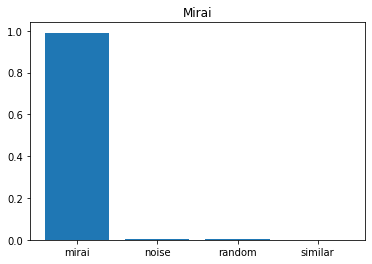

In [ ]:
new_model = tf.keras.models.load_model('new_mirai.h5')


x = data_dir/'mirai/audio_50.wav'
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = get_spectrogram(x)
x = x[tf.newaxis,...]
print(x.shape)
prediction = new_model(x)
plt.bar(commands, tf.nn.softmax(prediction[0]))
plt.title('Mirai')
plt.show()

display.display(display.Audio(waveform, rate=16000))

In [ ]:
!pip list

Package                      Version
---------------------------- --------------------
absl-py                      1.2.0
anyio                        3.6.1
appdirs                      1.4.4
argon2-cffi                  21.3.0
argon2-cffi-bindings         21.2.0
asttokens                    2.0.5
astunparse                   1.6.3
attrs                        21.4.0
audioread                    2.1.9
audiosegment                 0.23.0
Babel                        2.10.3
backcall                     0.2.0
beautifulsoup4               4.11.1
bleach                       5.0.1
Brotli                       1.0.9
cachetools                   5.2.0
certifi                      2022.6.15
cffi                         1.15.1
charset-normalizer           2.1.0
click                        8.1.3
colorama                     0.4.5
cycler                       0.11.0
debugpy                      1.6.2
decorator                    5.1.1
defusedxml                   0.7.1
dill                      